In [47]:
import warnings
warnings.filterwarnings('ignore')

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from flonacomldft.utils.io_utils import (
    load_pickle_file,
    get_path
)

from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.diagnostics import R_hat

from flonacomldft.utils.plots import (
    set_plot_sequential_data,
    plot_energy_surface,
    plot_energy_histogram,
)

from numpy.lib.stride_tricks import sliding_window_view

import matplotlib.pylab as pylab

size=16
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

In [49]:
# paths
DFT_DATA_PATH = get_path() + '/andersen/'
DFT_SIMS_PATH = '/mnt/home/amolina/ceph/adaptive-350/adaptive-dft/'

## 1. MCMC with mixture of isomers

In [50]:
# simulation files
mcmc_paths = ['5-multimodal/results_multimodal_sampling_mixture_29096190/mixture_mcmc_dic_29096190.pkl',
             #'6-multimodal-mlp/results_multimodal_sampling_mixture_29134160/mixture_mcmc_dic_29134160.pkl',
             #'6-multimodal-mlp/results_multimodal_sampling_mixture_29134161/mixture_mcmc_dic_29134161.pkl',
             '6-multimodal-mlp/results_multimodal_sampling_mixture_29797110/mixture_mcmc_dic_29797110.pkl',
             #'6-multimodal-mlp/results_multimodal_sampling_mixture_29681760/mixture_mcmc_dic_29681760.pkl', #alpha 0.1
             '6-multimodal-mlp/results_multimodal_sampling_mixture_29681651/mixture_mcmc_dic_29681651.pkl' #alpha 0.5
             ]

# load mcmc results
keys = ['DFT-DFT', 'DFT-MLP', 'MLP-MLP']
color_keys = dict(zip(keys, ['blue', 'orange', 'red']))
mcmcs = {key: load_pickle_file(mcmc_path, DFT_SIMS_PATH) for mcmc_path, key in zip(mcmc_paths, keys)}

### 1.a Acceptance ratio

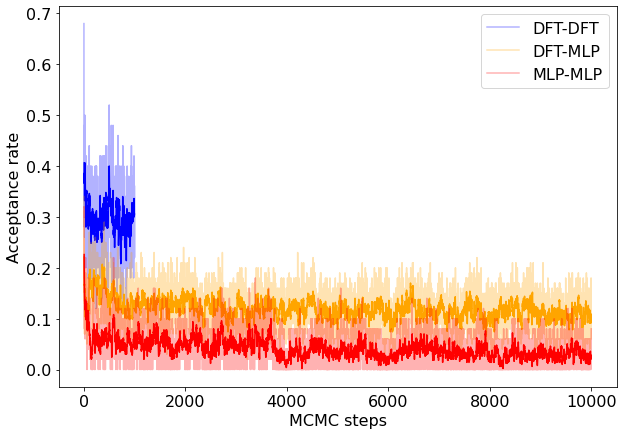

In [51]:
accs = {key: mcmcs[key]['accs'].mean(dim=1).detach() for key in mcmcs.keys()}

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in accs.keys():

    set_plot_sequential_data(accs[key], ax=ax, label=key, color=color_keys[key])
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Acceptance rate')

ax.legend()

### 1.b Collective variables

In [8]:
def get_collective_variable(simulation, etype='dft', Nsamples=10000):

    coord_mapping = Coordinates_mapping(etype=etype)

    xs = simulation['xs']
    xs_flatten = xs.reshape(-1, 12)

    isomers_mask = simulation['isomers'].reshape(-1, 1)

    xs_is0 = []
    xs_is1 = []

    for isomer, x in zip(isomers_mask, xs_flatten):
        if isomer==0:
            xs_is0.append(x)
        elif isomer==1:
            xs_is1.append(x)
        else:
            raise Warning('Not found!')

    xs_is0 = torch.stack(xs_is0)[-Nsamples:] 
    xs_is1 = torch.stack(xs_is1)

    cvs_is0 = coord_mapping.get_collective_variables_from_real_centered(xs_is0, isomer=0)
    cvs_is1 = coord_mapping.get_collective_variables_from_real_centered(xs_is1, isomer=1)

    return cvs_is0, cvs_is1


In [14]:
cvs = {key: get_collective_variable(mcmcs[key]) for key in mcmcs.keys()}

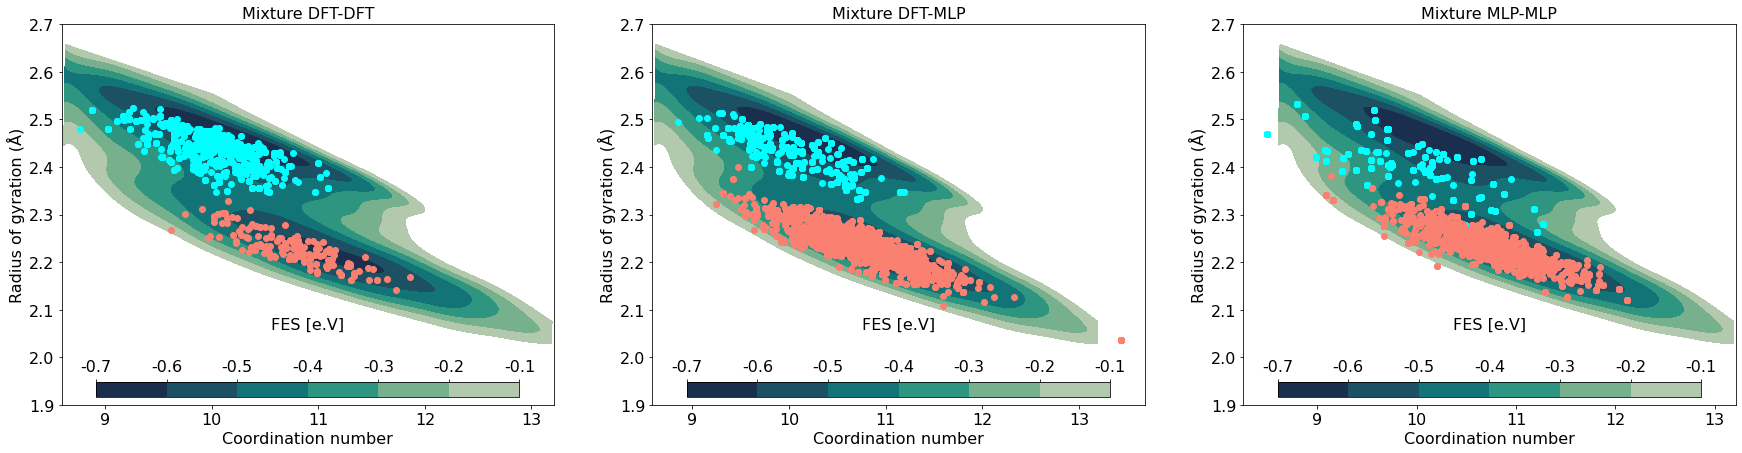

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(30, 7))

axs = axs.ravel()

for ax, key in zip(axs, cvs.keys()):

    plot_energy_surface(fig=fig, ax=ax)

    ax.scatter(cvs[key][0][:, 0], cvs[key][0][:, 1], c='cyan')
    ax.scatter(cvs[key][1][:, 0], cvs[key][1][:, 1], c='salmon')
    ax.set_title('Mixture {:s}'.format(key))


### 1.c Jumps between isomers

In [9]:
def plot_jums_along_chains(ax, isomers, size=6):

    isomers = isomers.T

    for i in range(isomers.shape[0]):

        jumps, counts = isomers[i].unique_consecutive(return_counts=True)

        colors_array = []
        
        for j in range(jumps.shape[0]):
            if jumps[j]==0:
                colors_array.append('cyan')
            else:
                colors_array.append('salmon')
        
        ax.plot(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), 'k--', alpha=0.4)
        ax.scatter(torch.ones(jumps.shape[0])*i, np.arange(0, jumps.shape[0]), s=counts*size, color=colors_array)
    
    ax.set_xlabel('Chains')
    ax.set_ylabel('Jumps')

In [10]:
isomers = {key: mcmcs[key]['isomers'] for key in mcmcs.keys()}

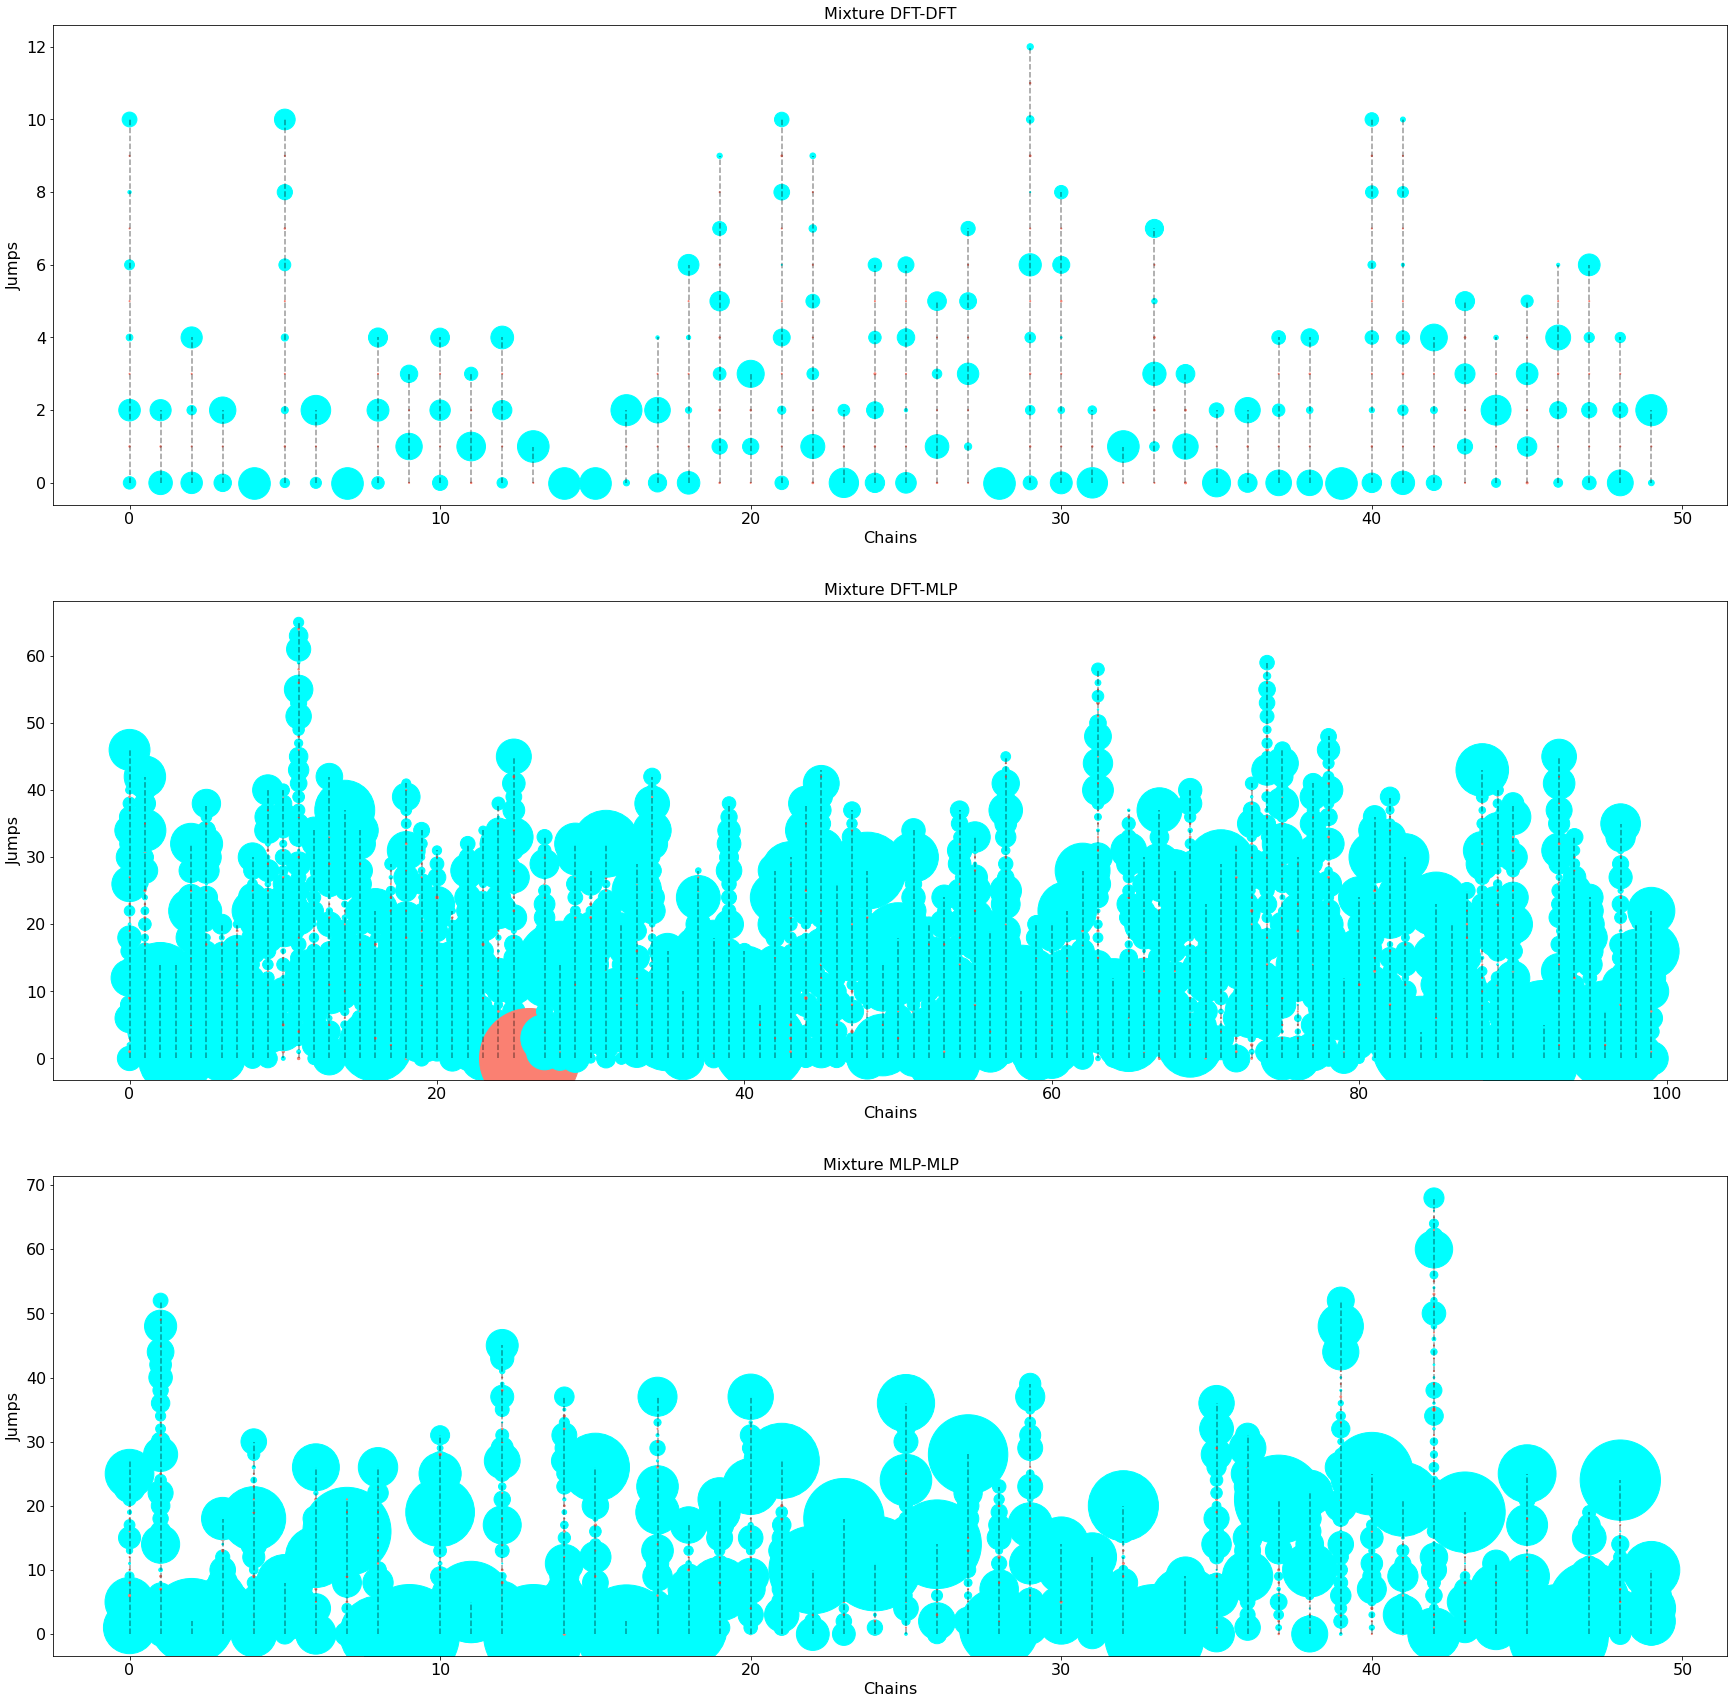

In [11]:
fig, axs = plt.subplots(3, 1, figsize=(30, 30))

axs = axs.ravel()

for ax, key in zip(axs, isomers.keys()):
    plot_jums_along_chains(ax, isomers[key], size=1)

    ax.set_title('Mixture {:s}'.format(key))

In [12]:
def plot_jumps_along_steps(ax, isomers):

    ax.plot(isomers.detach().numpy(), '.-')
    ax.set_xlabel('MCMC steps')
    ax.set_ylabel('Isomer')

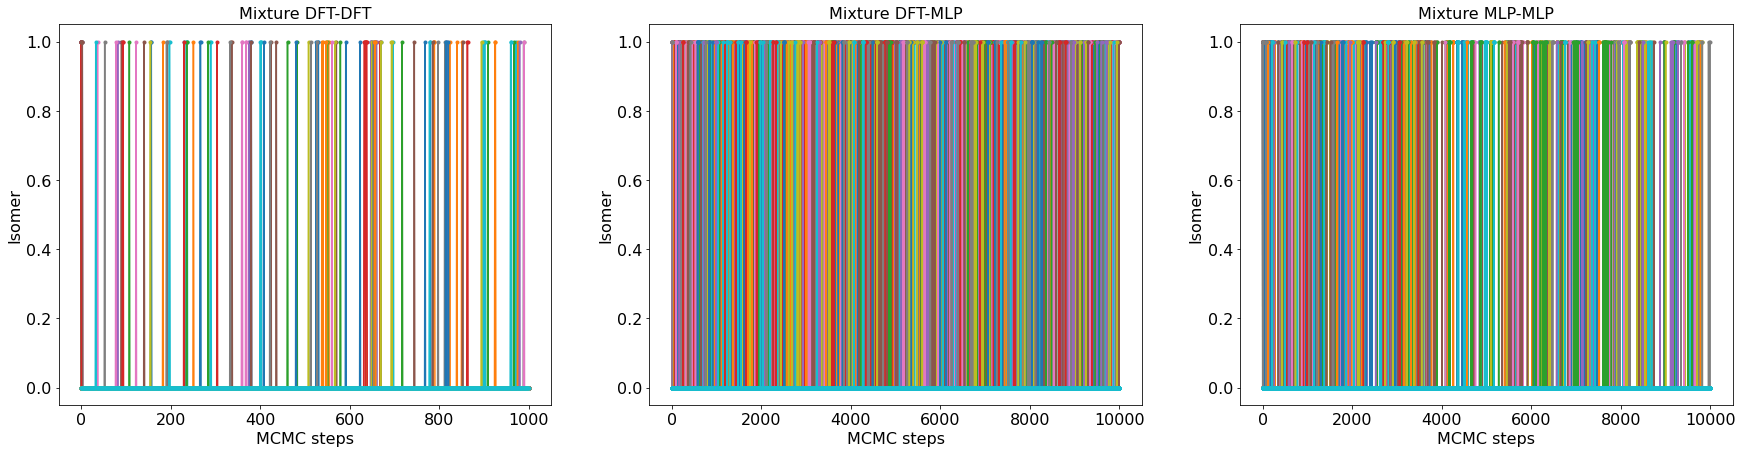

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(30, 7))

axs = axs.ravel()

for ax, key in zip(axs, isomers.keys()):
    plot_jumps_along_steps(ax, isomers[key])

    ax.set_title('Mixture {:s}'.format(key))

### 1.d Rhat test

In [15]:
def plot_rhat(ax, rhat):

    ax.plot(rhat[1], rhat[0], '-o',  label=rhat[2])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(r'$\hat{R}$')

In [16]:
xs = {key: mcmcs[key]["xs"].detach() for key in mcmcs.keys()}

In [17]:
zmats = {key: get_zmat_from_real(xs[key], isomers[key]) for key in xs.keys()}

rhat_s = {key: R_hat(zmats[key], n_split=100) for key in ['DFT-MLP', 'MLP-MLP']}
rhat_s['DFT-DFT'] = R_hat(zmats['DFT-DFT'], n_split=10)

In [30]:
#fig, axs = plt.subplots(1, 3, figsize=(30, 7), sharey=True)
#
#axs = axs.ravel()
#
#for ax, key in zip(axs, rhat_s.keys()):
#    plot_rhat(ax, rhat_s[key])
#
#    ax.set_title('Mixture {:s}'.format(key))

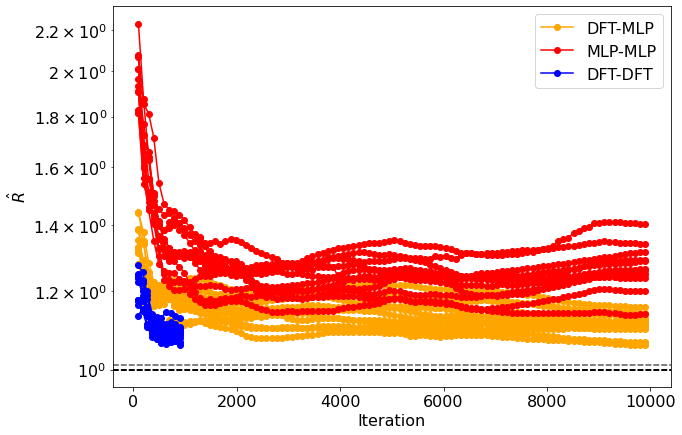

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
for key in rhat_s.keys():
    ax.plot(rhat_s[key][1], rhat_s[key][0], '-o',  label=key, color=color_keys[key])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(r'$\hat{R}$')
    ax.set_yscale('log')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    ax.legend(by_label.values(), by_label.keys())

### 1.e Energies

Text(0.5, 1.0, 'Energy histogram')

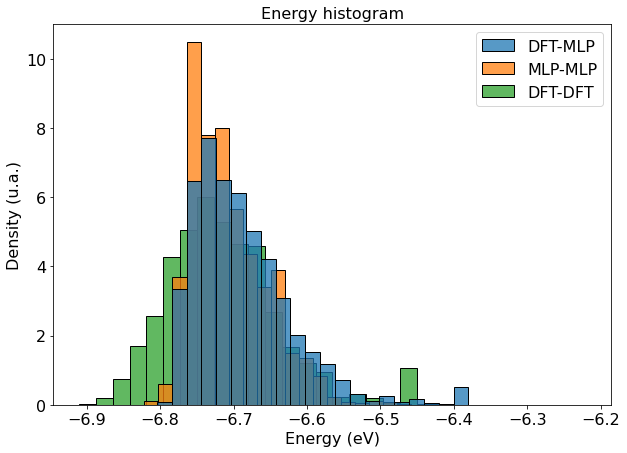

In [19]:
us = {key: mcmcs[key]['us'].flatten().detach() for key in mcmcs.keys()}

fig, axs = plt.subplots(1, 1, figsize=(10, 7))

plot_energy_histogram(us, ax=axs, bins=30, alpha=0.75, hue_order=['DFT-MLP', 'MLP-MLP', 'DFT-DFT'], common_bins=False, common_norm=False)
axs.set_title(f'Energy histogram')

In [73]:
#mlps = {i: load_pickle_file('dict_mlp_model_is{:d}_adaptive.pkl'.format(i), get_path() + '/andersen/models') for i in [0, 1]}

In [74]:
#upper = -6.6
#selected_us = mcmcs['DFT-DFT']['us']<upper
#indices = torch.nonzero(selected_us)

In [75]:
#target_us = torch.stack([mcmcs['DFT-DFT']['us'][i[0]][i[1]] for i in indices])

In [76]:
#selected_xs = torch.stack([mcmcs['DFT-DFT']['xs'][i[0]][i[1]] for i in indices])

In [77]:
#selected_isomers = torch.stack([mcmcs['DFT-DFT']['isomers'][i[0]][i[1]] for i in indices])

In [78]:
#masks = [~selected_isomers.bool(), selected_isomers.bool()]
#sel_xs = {i: selected_xs[mask] for i, mask in enumerate(masks)}
#
#sel_us_target = {i: target_us[mask] for i, mask in enumerate(masks)}

In [79]:
#us_pred = {i: mlps[i]['models'][-1](sel_xs[i]) for i in range(2)}

In [80]:
#fig, axs = plt.subplots(1, 2, figsize=(20, 7))
#axs = axs.ravel()
#
#for i, ax in enumerate(axs):
#    ax.plot(sel_us_target[i].flatten().detach(), us_pred[i].flatten().detach(), 'o')
#    ax.set_xlabel('Target')
#    ax.set_ylabel('Prediction')
#    ax.plot([-6.9, upper], [-6.9, upper], 'k--')
#    ax.set_title(f'Isomer {i}')

In [48]:
#us = {key: mcmcs[key]['us'] for key in mcmcs.keys()}
#
#nrows = 25
#
#us_splitted = {key: torch.stack([us[key][i*nrows: (i+1)*nrows, :].flatten().detach() for i in range(4)])
#                    for key in mcmcs.keys()}

In [81]:
#fig, axs = plt.subplots(3, 4, figsize=(40, 21), sharex=True)
#
#for ax, key in zip(axs, us_splitted.keys()):
#    for i, u in enumerate(us_splitted[key]):
#        ax[i].hist(u, bins=30, label=i, density=True)
#        ax[i].legend()
#        ax[i].set_title(key)

### 1.f Populations

In [98]:
def compute_population_windows(isomers, window_size=50):

    isomers = torch.cat((isomers[:, :16], isomers[:, 16 + 1:]), dim=1)

    isomers_window = sliding_window_view(isomers.detach().numpy(), window_shape=window_size, axis=0)
    population_window = np.array([isomer_window.mean() for isomer_window in isomers_window])

    return population_window

In [99]:
populations_is1 = {key: compute_population_windows(isomers[key], 1) for key in isomers.keys()}

(0.0, 0.04)

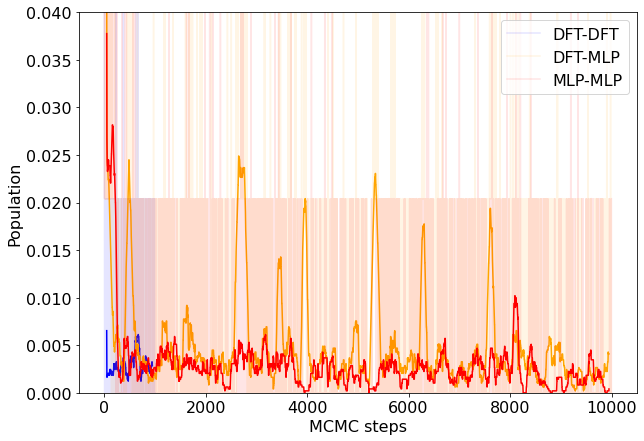

In [104]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in populations_is1.keys():
    set_plot_sequential_data(populations_is1[key], avg=True, window_size=100, ax=ax, label=key, color=color_keys[key], alpha=0.1)

ax.set_xlabel('MCMC steps')
ax.set_ylabel('Population')
ax.legend()

ax.set_ylim(0, 0.04)

In [89]:
for key in populations_is1.keys():
    print(f'Population {key}: {populations_is1[key][500:].mean()}')

Population DFT-DFT: 0.003459717845544219
Population DFT-MLP: 0.00448853662237525
Population MLP-MLP: 0.002414766699075699


### 1.g Time simulations

In [90]:
time_mcmc = {}
time_mcmc_window = {}

for key in mcmcs.keys():
    time_list = mcmcs[key]['time_mcmc']
    time_init = time_list[0]
    final_time = [(t - time_init)/3600 for t in time_list]
    time_mcmc[key] = final_time
    time_mcmc_window[key] = sliding_window_view(final_time, 100, axis=0).mean(axis=1)


In [91]:
time_mcmc_window['DFT-DFT'].shape, populations_is1['DFT-DFT'].shape

((901,), (901,))

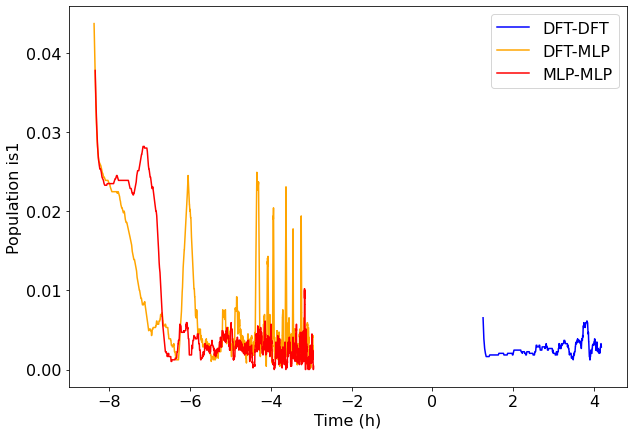

In [92]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7), sharey=True)

for key in keys:
    set_plot_sequential_data(y=populations_is1[key], x=np.log(time_mcmc_window[key]), avg=False, window_size=150, ax=ax, label=key, color=color_keys[key], alpha=1)
    ax.legend()
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Population is1')

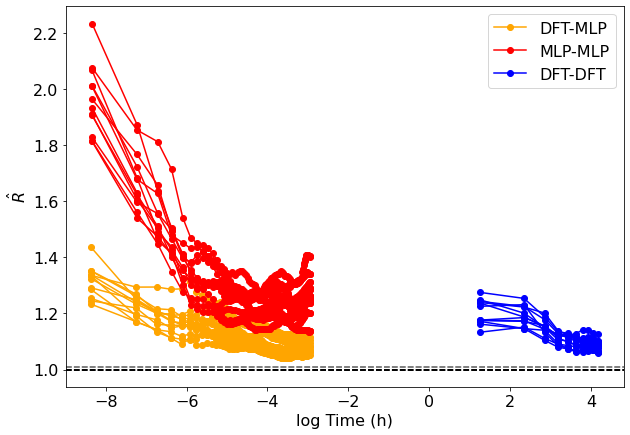

In [93]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7), sharey=True)

for key in rhat_s.keys():
    ax.plot(np.log(time_mcmc_window[key][::100]), rhat_s[key][0], '-o',  label=key, color=color_keys[key])
    ax.axhline(1, c='k', ls='--')
    ax.axhline(1.01, c='grey', ls='--')
    ax.set_xlabel('log Time (h)')
    ax.set_ylabel(r'$ \hat{R}$')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    ax.legend(by_label.values(), by_label.keys())

### 4.e Acceptance ratio histogram windows

In [70]:
accs = {key: mcmcs[key]['accs'].detach() for key in mcmcs.keys()}

In [73]:
#nchains=50
#nrow=160
#accs_slides_per_chain=[]
#arrs_slides_per_chain = []
#for chain in range(nchains):
#    arr = sliding_window_view(accs['DFT-DFT'][:, chain], 100, axis=0).mean(axis=1)
#    slides = []
#    for i in range(6):
#        slides.append(arr[i*nrows:(i+1)*nrows])
#    accs_slides_per_chain.append(slides)
#    arrs_slides_per_chain.append(arr)

In [74]:
#fig, axs = plt.subplots(10, 1, figsize=(10, 50))
#axs = axs.ravel()
#for k, ax in zip(list(range(0, 50, 5)), axs):
#    i=k
#    for arr in arrs_slides_per_chain[k:k+5]:
#        ax.plot(arr, label=i)
#        ax.legend()
#        ax.set_xlabel('MCMC steps')
#        ax.set_ylabel('Acceptance rate avg')
#        i=i+1

In [119]:
import random
def generate_random_color():
    # Generate random RGB values
    red = random.uniform(0, 1)
    green = random.uniform(0, 1)
    blue = random.uniform(0, 1)

    # Return the RGB values as a tuple
    return red, green, blue

In [75]:
#step = 5
#for k in range(0, 50, step):
#    fig, axs = plt.subplots(3, 2, figsize=(20, 21))
#    axs = axs.ravel()
#    i=0
#    for j in range(k, k+step):
#        color = generate_random_color()
#        for acc, ax in zip(accs_slides_per_chain[j], axs):
#            ax.hist(acc, label=j, color=color, bins=5, density=True)
#            ax.legend()
#            ax.set_title('Chains from {:d} to {:d}'.format(k, k+10))
#            ax.set_xlabel('Acceptance rate')
#            ax.set_xlim(-0.1, 0.5)

In [76]:
#chains_low_accs=[14, 31, 35, 36, 39, 49]
#fig, axs = plt.subplots(2, 3, figsize=(30, 14))
#axs = axs.ravel()
#for i, ax in zip(chains_low_accs, axs):
#    for j, acc in enumerate(accs_slides_per_chain[i]):
#        ax.hist(acc, label=j, bins=5)
#        ax.legend()
#        ax.set_title('Chain {:d}'.format(i))
#        ax.set_xlabel('Acceptance rate')
#        ax.set_xlim(-0.1, 0.5)

In [ ]:
us_splitted = {key: torch.stack([us[key][i*nrows: (i+1)*nrows, :].flatten().detach() for i in range(4)])
                    for key in mcmcs.keys()}



In [79]:
accs = {key: mcmcs[key]['us'].detach() for key in mcmcs.keys()}

RuntimeError: shape '[20, 50]' is invalid for input of size 50000

In [83]:
accs['DFT-DFT'].reshape(20, 2500)

tensor([[-6.7723, -6.7025, -6.6735,  ..., -6.8207, -6.7718, -6.6924],
        [-6.6408, -6.7835, -6.7692,  ..., -6.7126, -6.6061, -6.7223],
        [-6.6632, -6.5416, -6.8648,  ..., -6.7767, -6.6703, -6.6501],
        ...,
        [-6.8656, -6.6816, -6.7078,  ..., -6.6861, -6.6647, -6.8069],
        [-6.5828, -6.7916, -6.7756,  ..., -6.7868, -6.8391, -6.6901],
        [-6.8113, -6.6951, -6.6711,  ..., -6.6849, -6.7309, -6.6901]])

In [170]:
def get_accs_windows(accs, reshape_size):
    return accs.reshape(reshape_size)

#get_accs_windows(accs['DFT-DFT'], (10, 100)).shape

In [176]:
accs_window = {}

for key in ['DFT-MLP']:#accs.keys():
    accs_window[key] = get_accs_windows(accs[key], (4, 250, 1000)).reshape(4, -1)

In [178]:
[acc.flatten().shape for acc in accs_window['DFT-MLP']]

[torch.Size([250000]),
 torch.Size([250000]),
 torch.Size([250000]),
 torch.Size([250000])]

In [179]:
accs_windows = {}
accs_windows['DFT-MLP'] = dict(zip(list(range(0, 4)), accs_window['DFT-MLP']))

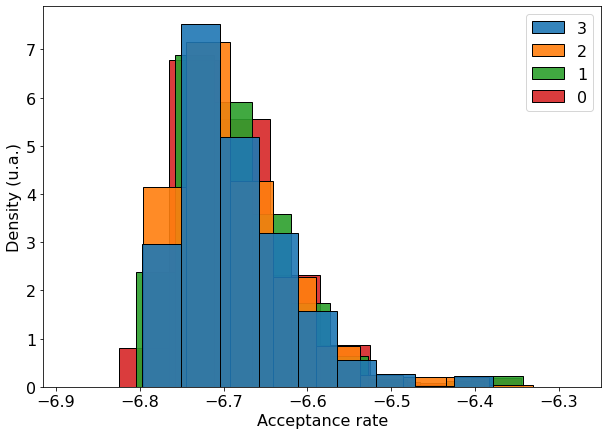

In [181]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

for key in ['DFT-MLP']:
    plot_energy_histogram(accs_windows[key], ax=ax, bins=10, alpha=0.9, common_bins=False, common_norm=False, hue_order=list(range(0, 4))[::-1])
    
    #ax.set_title('Acceptance rate window {:d}'.format(key))
    ax.set_xlabel('Acceptance rate')

In [133]:
from flonacomldft.utils.io_utils import load_pickle_file

In [134]:
mlps = {i: load_pickle_file('dict_mlp_model_is{:d}_adaptive.pkl'.format(i), get_path() + '/andersen/models') for i in [0, 1]}

In [145]:
xs = mcmcs['DFT-DFT']['xs']
isomers = mcmcs['DFT-DFT']['isomers']
us = mcmcs['DFT-DFT']['us']

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

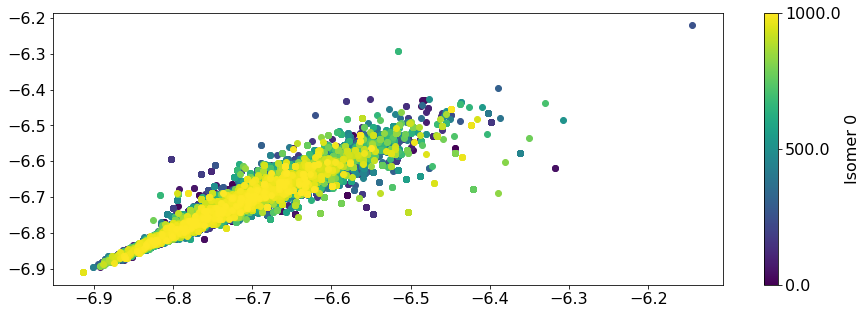

In [160]:
cmap_name = 'viridis'
cmap = plt.get_cmap(cmap_name)
num_colors = 1000
values = np.linspace(0, 1, num_colors)
colors = cmap(values)


for i in range(1000):   
    plt.scatter(mlps[0]['models'][-5](xs[i][isomers[i]==0]).flatten().detach(), us[i][isomers[i]==0].flatten().detach(), c=colors[i])

cbar = plt.colorbar(label='Isomer 0')
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(np.array([0, 0.5, 1])*1000)

In [167]:
us_flatten = mcmcs['MLP-MLP']['us'].flatten()

us_flatten[us_flatten<-6.8].shape

torch.Size([1179])

In [168]:
us_flatten = mcmcs['DFT-MLP']['us'].flatten()

us_flatten[us_flatten<-6.8].shape

torch.Size([48])

In [169]:
us_flatten = mcmcs['DFT-DFT']['us'].flatten()

us_flatten[us_flatten<-6.8].shape

torch.Size([5409])